In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Görselleştirme Teması
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("Bank_Customer_Churn.csv")

In [5]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print(f"Toplam Satır (Müşteri): {df.shape[0]}, Toplam Sütun: {df.shape[1]}")
df.head()

Toplam Satır (Müşteri): 10000, Toplam Sütun: 12


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
print("--- Veri Tipleri ve Boş Değer Kontrolü ---")
print(df.info())

--- Veri Tipleri ve Boş Değer Kontrolü ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


In [8]:
print("\n--- Eksik Değer Özeti ---")
print(df.isnull().sum())


--- Eksik Değer Özeti ---
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


In [9]:
print("\n--- Sayısal Değişkenlerin İstatistiksel Özeti ---")
df.describe().T


--- Sayısal Değişkenlerin İstatistiksel Özeti ---


,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


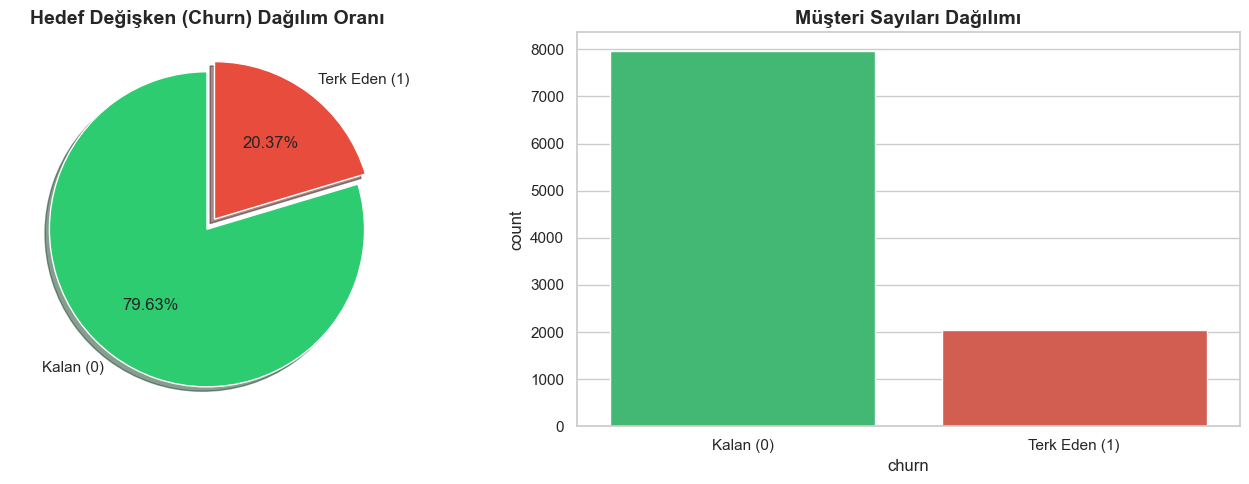

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Pasta Grafiği
churn_counts = df['churn'].value_counts()
ax[0].pie(churn_counts, labels=['Kalan (0)', 'Terk Eden (1)'], autopct='%1.2f%%', 
          explode=[0, 0.08], colors=['#2ecc71', '#e74c3c'], startangle=90, shadow=True)
ax[0].set_title('Hedef Değişken (Churn) Dağılım Oranı', fontsize=14, fontweight='bold')

# 2. Sayım Grafiği
sns.countplot(data=df, x='churn', ax=ax[1], palette=['#2ecc71', '#e74c3c'])
ax[1].set_title('Müşteri Sayıları Dağılımı', fontsize=14, fontweight='bold')
ax[1].set_xticklabels(['Kalan (0)', 'Terk Eden (1)'])

plt.tight_layout()
plt.show()

In [11]:
cat_cols = ['country', 'gender', 'credit_card', 'active_member', 'products_number']

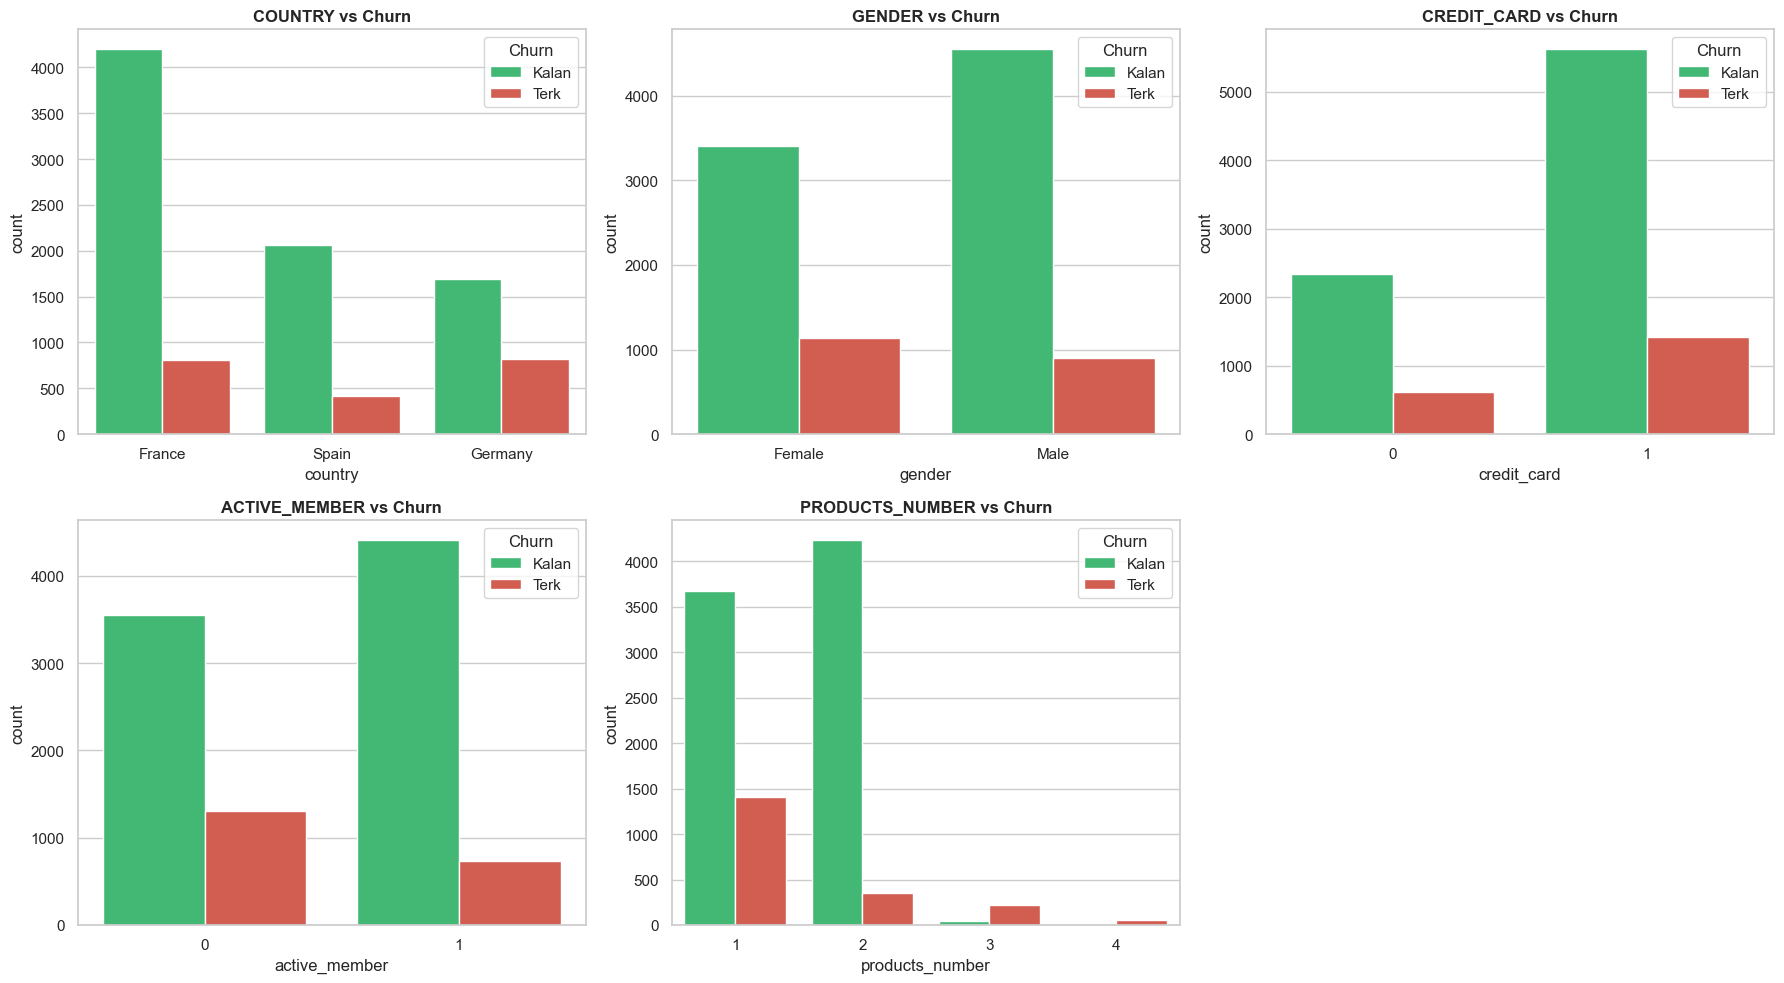

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='churn', ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col.upper()} vs Churn', fontsize=12, fontweight='bold')
    axes[i].legend(title='Churn', labels=['Kalan', 'Terk'])

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

In [13]:
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

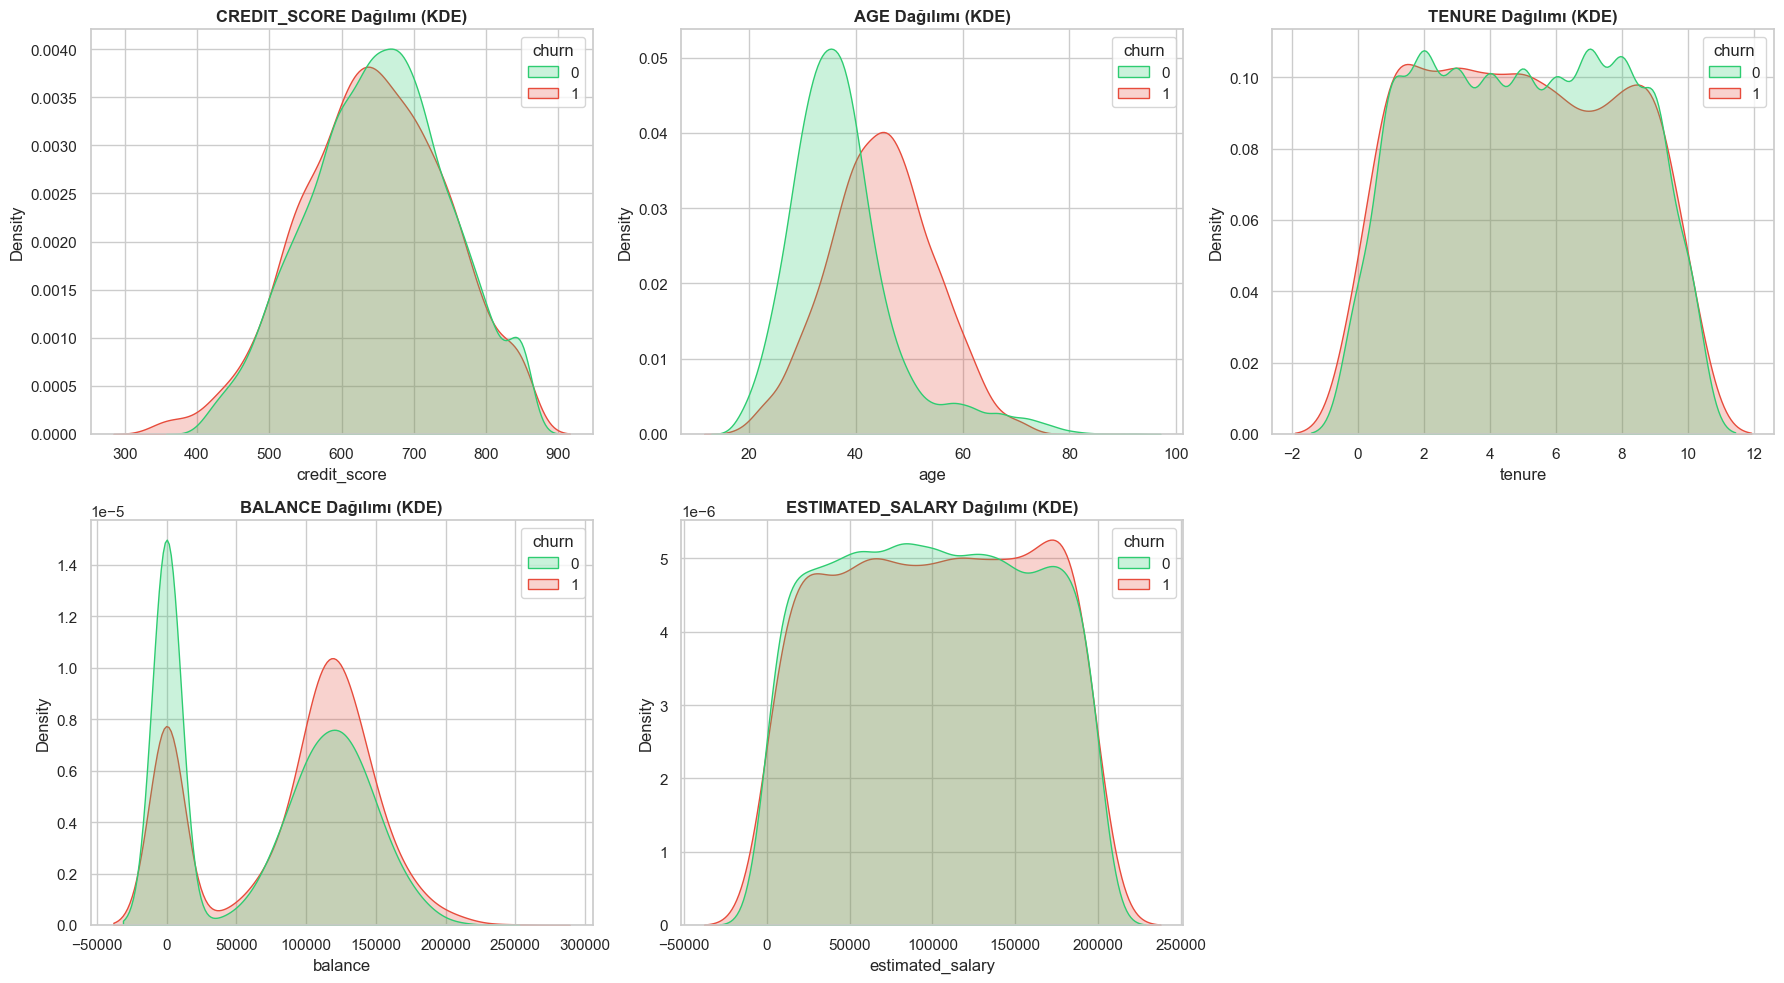

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue='churn', fill=True, common_norm=False, 
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col.upper()} Dağılımı (KDE)', fontsize=12, fontweight='bold')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

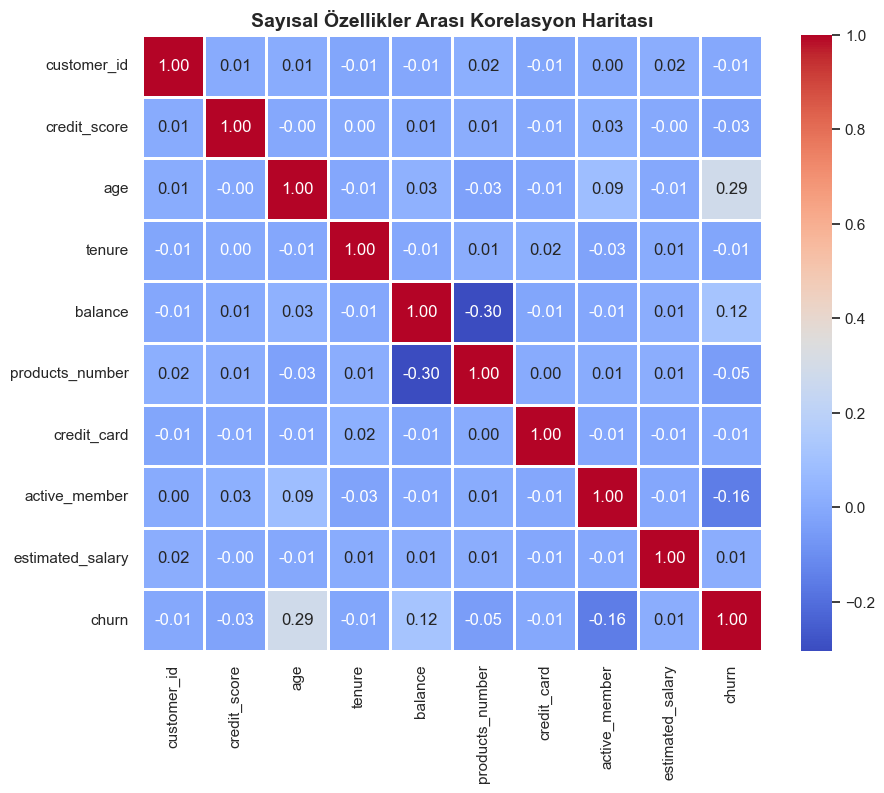

In [15]:
plt.figure(figsize=(10, 8))
numeric_data = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
plt.title('Sayısal Özellikler Arası Korelasyon Haritası', fontsize=14, fontweight='bold')
plt.show()

In [16]:
df_proc = df.copy()

In [17]:
#  Anlamsız ID Sütununu Çıkarma
if 'customer_id' in df_proc.columns:
    df_proc.drop('customer_id', axis=1, inplace=True)

In [18]:
#  FEATURE ENGINEERING

In [19]:
# Bakiye / Maaş Oranı (Müşterinin varlığı maaşına kıyasla ne kadar?)
df_proc['balance_salary_ratio'] = df_proc['balance'] / (df_proc['estimated_salary'] + 1)

In [20]:
# Yaş / Sadakat Süresi Oranı
df_proc['age_tenure_ratio'] = df_proc['age'] / (df_proc['tenure'] + 1)

In [21]:
# Sıfır Bakiye Flag'i (Bakiyesi 0 olan müşteriler özel bir davranış sergiler)
df_proc['is_zero_balance'] = (df_proc['balance'] == 0).astype(int)

In [22]:
# Yaş Segmentasyonu
df_proc['age_group'] = pd.cut(df_proc['age'], bins=[0, 30, 45, 60, 100], labels=['Genc', 'Orta', 'Olgun', 'Yasli'])

In [23]:
#encoding

In [24]:
# Nominal sütunlara One-Hot Encoding
df_proc = pd.get_dummies(df_proc, columns=['country', 'gender', 'age_group'], drop_first=True)

In [25]:
print("İşlem Sonrası Kolonlar:")
print(df_proc.columns.tolist())
df_proc.head()

İşlem Sonrası Kolonlar:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn', 'balance_salary_ratio', 'age_tenure_ratio', 'is_zero_balance', 'country_Germany', 'country_Spain', 'gender_Male', 'age_group_Orta', 'age_group_Olgun', 'age_group_Yasli']


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,balance_salary_ratio,age_tenure_ratio,is_zero_balance,country_Germany,country_Spain,gender_Male,age_group_Orta,age_group_Olgun,age_group_Yasli
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,14.000000,1,False,False,False,True,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,20.500000,0,False,True,False,True,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,4.666667,0,False,False,False,True,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,19.500000,1,False,False,False,True,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,14.333333,0,False,True,False,True,False,False


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [27]:
X = df_proc.drop('churn', axis=1)
y = df_proc['churn']

In [28]:
# 1. Veriyi Bölme (stratify=y: Sınıf dengesizliğini train ve testte eşit tutar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [29]:
# 2. Ölçeklendirme (Data Leakage'ı engellemek için sadece train fit edilir!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
print(f"Eğitim Seti Boyutu: {X_train.shape}")
print(f"Test Seti Boyutu: {X_test.shape}")

Eğitim Seti Boyutu: (8000, 17)
Test Seti Boyutu: (2000, 17)


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [32]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

In [33]:
results = []

for name, model in models.items():
    # Modeli eğit
    model.fit(X_train_scaled, y_train)
    
    # Tahminleri üret
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_pred
    
    # Metrikleri hesapla
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

# Sonuçları ROC-AUC'ye göre sırala
df_results = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print("=== MODEL BENCHMARK SIRALAMASI ===")
df_results

=== MODEL BENCHMARK SIRALAMASI ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
5,Gradient Boosting,0.8735,0.8156,0.4889,0.6114,0.8725
7,LightGBM,0.8630,0.7491,0.4914,0.5935,0.8593
3,Random Forest,0.8595,0.7625,0.4496,0.5657,0.8506
4,AdaBoost,0.8590,0.7854,0.4226,0.5495,0.8493
6,XGBoost,0.8555,0.7201,0.4742,0.5719,0.8355
0,Logistic Regression,0.8315,0.6902,0.3120,0.4298,0.7907
1,KNN,0.8315,0.6483,0.3759,0.4759,0.7636
2,Decision Tree,0.7910,0.4871,0.5111,0.4988,0.6868


In [34]:
from sklearn.model_selection import RandomizedSearchCV

In [35]:
# XGBoost Hiperparametre Havuzu
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

print(f"\nEn İyi Parametreler: {random_search.best_params_}")
print(f"En İyi CV ROC-AUC Skoru: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

En İyi Parametreler: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
En İyi CV ROC-AUC Skoru: 0.8659


In [36]:
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
best_model = random_search.best_estimator_
y_final_pred = best_model.predict(X_test_scaled)
y_final_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("=== FINAL MODEL CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_final_pred))
print(f"Final Test ROC-AUC Skoru: {roc_auc_score(y_test, y_final_prob):.4f}")

=== FINAL MODEL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.82      0.45      0.58       407

    accuracy                           0.87      2000
   macro avg       0.85      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

Final Test ROC-AUC Skoru: 0.8639


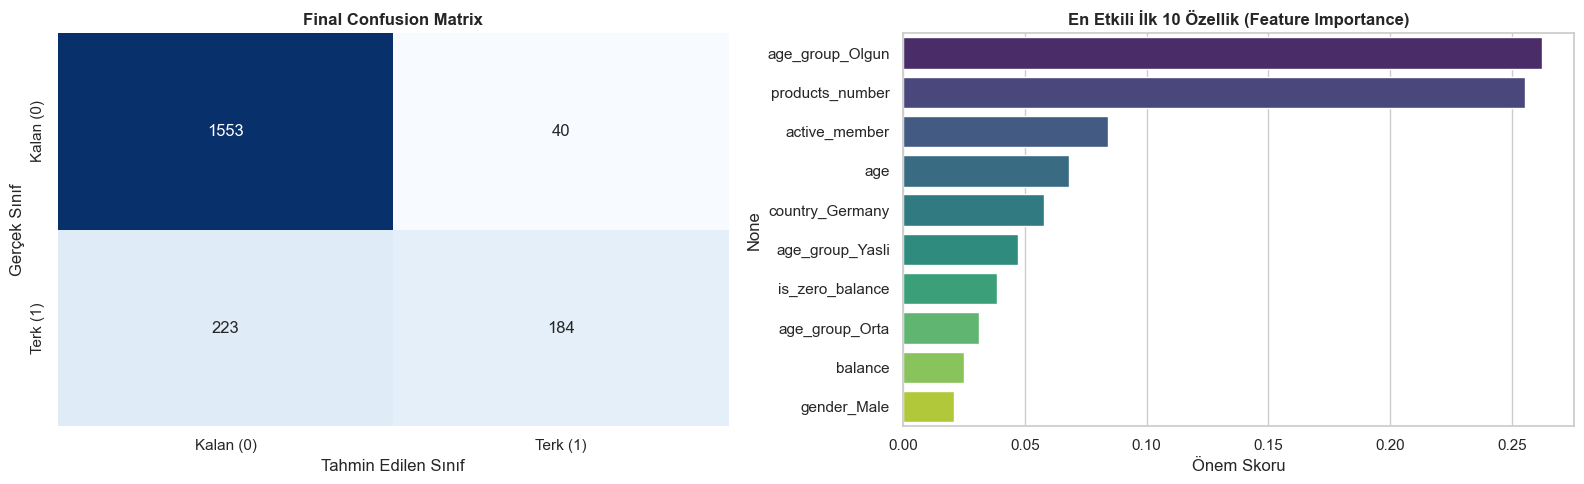

In [38]:
# 1. Confusion Matrix Görseli
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('Final Confusion Matrix', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Tahmin Edilen Sınıf')
ax[0].set_ylabel('Gerçek Sınıf')
ax[0].set_xticklabels(['Kalan (0)', 'Terk (1)'])
ax[0].set_yticklabels(['Kalan (0)', 'Terk (1)'])

# 2. Feature Importance (En Önemli Değişkenler)
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis', ax=ax[1])
ax[1].set_title('En Etkili İlk 10 Özellik (Feature Importance)', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Önem Skoru')

plt.tight_layout()
plt.show()